# Approach B: Siamese BiLSTM with Stylometric Features
## Authorship Verification — COMP34812 Coursework

**Task:** Given two text sequences, predict whether they were written by the same author (1) or different authors (0).

**Approach Category:** B — Deep learning without transformer architectures.

**Architecture Overview:**
1. **Stylometric feature extraction** — handcrafted features capturing writing style (punctuation habits, vocabulary richness, sentence structure, etc.)
2. **Siamese BiLSTM with attention** — shared-weight bidirectional LSTM encodes both texts using GloVe embeddings, with attention pooling
3. **Comparison network** — combines encoded representations via element-wise difference, product, and concatenation, plus stylometric feature differences
4. **Classification head** — fully connected layers → binary prediction

This notebook is structured so each section explains *what* and *why* before the code.


## 1. Setup & Installation

We install the required packages and set seeds for reproducibility. We use PyTorch as our deep learning framework.


In [1]:
# Install required packages (uncomment if running in Colab)
# !pip install torch torchtext pandas numpy scikit-learn matplotlib seaborn nltk tqdm

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import Counter
import re
import string
import warnings
import pickle
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Data Loading & Exploration

Let's load the training and dev sets and understand the data we're working with.

**Key things to check:**
- Class balance (is label 0 vs 1 roughly even?)
- Text length distributions (how long are the texts?)
- Any missing values or edge cases?


In [2]:
# --- Load data ---
# Update these paths for your environment (e.g., Colab upload or Google Drive mount)
TRAIN_PATH = 'train.csv'  # Update path as needed
DEV_PATH = 'dev.csv'                  # Update path as needed

train_df = pd.read_csv(TRAIN_PATH)
dev_df = pd.read_csv(DEV_PATH)

# Ensure label column is integer
train_df['label'] = train_df['label'].astype(int)
dev_df['label'] = dev_df['label'].astype(int)

print(f"Training set: {train_df.shape[0]} pairs")
print(f"Dev set:      {dev_df.shape[0]} pairs")
print(f"\nTraining label distribution:\n{train_df['label'].value_counts()}")
print(f"\nDev label distribution:\n{dev_df['label'].value_counts()}")


Training set: 27643 pairs
Dev set:      5993 pairs

Training label distribution:
label
0    13950
1    13693
Name: count, dtype: int64

Dev label distribution:
label
1    3056
0    2937
Name: count, dtype: int64


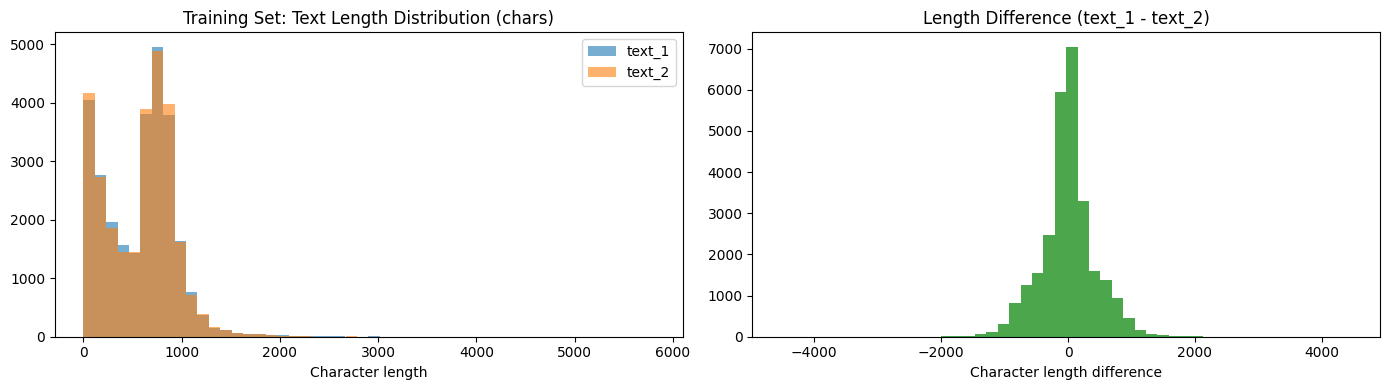

Missing values in train: 0
Missing values in dev:   0


In [3]:
# --- Text length analysis ---
for df, name in [(train_df, 'Train'), (dev_df, 'Dev')]:
    df['len_1'] = df['text_1'].str.len()
    df['len_2'] = df['text_2'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df['len_1'], bins=50, alpha=0.6, label='text_1')
axes[0].hist(train_df['len_2'], bins=50, alpha=0.6, label='text_2')
axes[0].set_title('Training Set: Text Length Distribution (chars)')
axes[0].set_xlabel('Character length')
axes[0].legend()

axes[1].hist(train_df['len_1'] - train_df['len_2'], bins=50, alpha=0.7, color='green')
axes[1].set_title('Length Difference (text_1 - text_2)')
axes[1].set_xlabel('Character length difference')
plt.tight_layout()
plt.show()

print(f"Missing values in train: {train_df[['text_1','text_2','label']].isnull().sum().sum()}")
print(f"Missing values in dev:   {dev_df[['text_1','text_2','label']].isnull().sum().sum()}")


## 3. Stylometric Feature Extraction

**Why stylometric features?**

Authorship verification isn't about *what* someone writes — it's about *how* they write. Two authors might discuss the same topic but use different punctuation patterns, vocabulary richness, sentence lengths, etc.

We extract features per text, then compute the **absolute difference** between each pair. This gives the model explicit signals about stylistic (dis)similarity.

**Features we extract per text:**
- **Lexical:** average word length, vocabulary richness (type-token ratio), proportion of long words
- **Punctuation:** frequency of commas, periods, exclamation marks, question marks, colons, semicolons, ellipses
- **Structural:** average sentence length, sentence count, paragraph-like structure
- **Character-level:** digit ratio, uppercase ratio, whitespace ratio
- **Function words:** proportion of stopwords (function words like "the", "is", "at" are strong authorship signals)


In [4]:
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def extract_stylometric_features(text):
    """
    Extract a vector of stylometric (writing style) features from a single text.

    Returns a dict of feature_name -> float.
    """
    features = {}

    # Handle edge cases
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {f: 0.0 for f in _get_feature_names()}

    # --- Basic counts ---
    chars = list(text)
    words = text.split()  # simple whitespace split for robustness
    num_chars = max(len(text), 1)
    num_words = max(len(words), 1)

    # --- Lexical features ---
    word_lengths = [len(w) for w in words]
    features['avg_word_length'] = np.mean(word_lengths)
    features['std_word_length'] = np.std(word_lengths) if len(word_lengths) > 1 else 0.0
    features['max_word_length'] = max(word_lengths) if word_lengths else 0.0

    # Type-token ratio (vocabulary richness)
    unique_words = set(w.lower() for w in words)
    features['type_token_ratio'] = len(unique_words) / num_words

    # Proportion of long words (>6 chars)
    features['long_word_ratio'] = sum(1 for w in words if len(w) > 6) / num_words

    # Proportion of short words (<=3 chars)
    features['short_word_ratio'] = sum(1 for w in words if len(w) <= 3) / num_words

    # --- Punctuation features ---
    features['comma_rate'] = text.count(',') / num_words
    features['period_rate'] = text.count('.') / num_words
    features['exclamation_rate'] = text.count('!') / num_words
    features['question_rate'] = text.count('?') / num_words
    features['colon_rate'] = text.count(':') / num_words
    features['semicolon_rate'] = text.count(';') / num_words
    features['ellipsis_rate'] = text.count('...') / num_words
    features['dash_rate'] = (text.count('-') + text.count('—')) / num_words
    features['quote_rate'] = (text.count('"') + text.count("'")) / num_words
    features['paren_rate'] = (text.count('(') + text.count(')')) / num_words

    # Total punctuation density
    punct_count = sum(1 for c in text if c in string.punctuation)
    features['punct_density'] = punct_count / num_chars

    # --- Structural features ---
    try:
        sentences = sent_tokenize(text)
    except:
        sentences = text.split('.')
    num_sentences = max(len(sentences), 1)

    sent_lengths = [len(s.split()) for s in sentences]
    features['avg_sentence_length'] = np.mean(sent_lengths)
    features['std_sentence_length'] = np.std(sent_lengths) if len(sent_lengths) > 1 else 0.0
    features['num_sentences'] = num_sentences
    features['words_per_text'] = num_words

    # --- Character-level features ---
    features['uppercase_ratio'] = sum(1 for c in text if c.isupper()) / num_chars
    features['digit_ratio'] = sum(1 for c in text if c.isdigit()) / num_chars
    features['whitespace_ratio'] = sum(1 for c in text if c.isspace()) / num_chars

    # --- Function word features ---
    lower_words = [w.lower() for w in words]
    features['stopword_ratio'] = sum(1 for w in lower_words if w in STOPWORDS) / num_words

    # --- Special tokens ---
    features['url_count'] = len(re.findall(r'http[s]?://\S+|urlLink', text)) / num_words
    features['emoji_like_rate'] = len(re.findall(r'[:;][\-]?[)(DPp/\\|]', text)) / num_words
    features['contraction_rate'] = len(re.findall(r"\w+'\w+", text)) / num_words
    features['capitalized_word_ratio'] = sum(1 for w in words if w[0].isupper() and len(w) > 1) / num_words

    return features


def _get_feature_names():
    """Return the list of feature names in a consistent order."""
    dummy = extract_stylometric_features("Hello world, this is a test.")
    return list(dummy.keys())


# --- Test it on a sample ---
sample_text = train_df.iloc[0]['text_1']
feats = extract_stylometric_features(sample_text)
print("Sample text (first 100 chars):", sample_text[:100])
print(f"\nExtracted {len(feats)} features:")
for k, v in feats.items():
    print(f"  {k:30s} = {v:.4f}")


Sample text (first 100 chars): halloween with kids is fun - getting them to bed - not so much. :)

Extracted 29 features:
  avg_word_length                = 3.4667
  std_word_length                = 2.1250
  max_word_length                = 9.0000
  type_token_ratio               = 0.9333
  long_word_ratio                = 0.1333
  short_word_ratio               = 0.6000
  comma_rate                     = 0.0000
  period_rate                    = 0.0667
  exclamation_rate               = 0.0000
  question_rate                  = 0.0000
  colon_rate                     = 0.0667
  semicolon_rate                 = 0.0000
  ellipsis_rate                  = 0.0000
  dash_rate                      = 0.1333
  quote_rate                     = 0.0000
  paren_rate                     = 0.0667
  punct_density                  = 0.0758
  avg_sentence_length            = 7.5000
  std_sentence_length            = 6.5000
  num_sentences                  = 2.0000
  words_per_text                 = 15.

In [5]:
def compute_pair_stylometric_features(df):
    """
    For each row in df, extract stylometric features for text_1 and text_2,
    then compute the absolute difference between them.

    Returns a numpy array of shape (len(df), num_features).
    """
    feature_names = _get_feature_names()
    all_diffs = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting stylometric features"):
        f1 = extract_stylometric_features(row['text_1'])
        f2 = extract_stylometric_features(row['text_2'])

        # Absolute difference captures stylistic dissimilarity
        diff = [abs(f1[k] - f2[k]) for k in feature_names]
        all_diffs.append(diff)

    return np.array(all_diffs, dtype=np.float32), feature_names

# Extract features for train and dev
print("Processing training set...")
train_style_feats, feat_names = compute_pair_stylometric_features(train_df)
print(f"\nProcessing dev set...")
dev_style_feats, _ = compute_pair_stylometric_features(dev_df)

print(f"\nStylometric feature matrix shapes:")
print(f"  Train: {train_style_feats.shape}")
print(f"  Dev:   {dev_style_feats.shape}")


Processing training set...


Extracting stylometric features:   0%|          | 0/27643 [00:00<?, ?it/s]


Processing dev set...


Extracting stylometric features:   0%|          | 0/5993 [00:00<?, ?it/s]


Stylometric feature matrix shapes:
  Train: (27643, 29)
  Dev:   (5993, 29)


In [6]:
# --- Normalise stylometric features (important for neural nets!) ---
from sklearn.preprocessing import StandardScaler

style_scaler = StandardScaler()
train_style_feats = style_scaler.fit_transform(train_style_feats)
dev_style_feats = style_scaler.transform(dev_style_feats)

print("Stylometric features normalised (zero mean, unit variance).")
print(f"Sample feature vector (first pair): {train_style_feats[0][:5]}...")


Stylometric features normalised (zero mean, unit variance).
Sample feature vector (first pair): [-0.00653081 -0.3022587  -0.09466955 -0.6921417  -0.07838059]...


## 4. Text Preprocessing & GloVe Embeddings

**Why GloVe?**

We need to convert words into numerical vectors. GloVe (Global Vectors for Word Representation) gives us pre-trained word embeddings that capture semantic meaning. Importantly, GloVe is *not* a transformer — it's a co-occurrence statistics-based method, so it's fair game for Approach B.

**Preprocessing steps:**
1. Lowercase the text
2. Tokenise into words
3. Build a vocabulary from the training set
4. Map each word to its GloVe vector (or a random vector for unknown words)
5. Pad/truncate sequences to a fixed length

We use **GloVe 6B 100d** — 100-dimensional vectors trained on 6 billion tokens. This is a good balance between expressiveness and memory.


In [7]:
# --- Download GloVe embeddings ---
# This downloads the 100d version (~350MB). Run once.
import urllib.request
import zipfile

GLOVE_DIR = 'glove'
GLOVE_PATH = os.path.join(GLOVE_DIR, 'glove.6B.100d.txt')
EMBED_DIM = 100

if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    print("Downloading GloVe embeddings (this may take a few minutes)...")
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    zip_path = os.path.join(GLOVE_DIR, "glove.6B.zip")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract('glove.6B.100d.txt', GLOVE_DIR)
    os.remove(zip_path)
    print("Done!")
else:
    print("GloVe embeddings already downloaded.")


Done!


In [8]:
# --- Build vocabulary from training data ---

MAX_VOCAB = 50000   # Keep top 50K most frequent words
MAX_LEN = 256       # Truncate/pad sequences to this length

def simple_tokenize(text):
    """
    Lowercase and tokenize. We use a simple regex-based tokenizer
    that's fast and handles most cases well.
    """
    text = text.lower().strip()
    # Split on whitespace and punctuation, keeping punctuation as tokens
    tokens = re.findall(r"\w+|[^\w\s]", text)
    return tokens

# Build word frequency counts from training data
print("Building vocabulary from training data...")
word_counts = Counter()
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    word_counts.update(simple_tokenize(row['text_1']))
    word_counts.update(simple_tokenize(row['text_2']))

# Special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Build word-to-index mapping
# Reserve index 0 for PAD, 1 for UNK
vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, count in word_counts.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")
print(f"Total unique words in training data: {len(word_counts)}")
print(f"Coverage: {sum(word_counts[w] for w in list(vocab.keys())[2:]) / sum(word_counts.values()):.2%}")


Building vocabulary from training data...


  0%|          | 0/27643 [00:00<?, ?it/s]

Vocabulary size: 50000
Total unique words in training data: 91113
Coverage: 99.29%


In [9]:
# --- Load GloVe and create embedding matrix ---

def load_glove(path, vocab, embed_dim):
    """
    Load GloVe vectors for words in our vocabulary.
    Returns an embedding matrix of shape (vocab_size, embed_dim).
    Words not in GloVe get random initialisation.
    """
    # Initialise with random vectors (for words not in GloVe)
    embedding_matrix = np.random.normal(0, 0.1, (len(vocab), embed_dim)).astype(np.float32)
    embedding_matrix[0] = 0  # PAD token should be zeros

    found = 0
    print("Loading GloVe vectors...")
    with open(path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Reading GloVe"):
            parts = line.rstrip().split(' ')
            word = parts[0]
            if word in vocab:
                embedding_matrix[vocab[word]] = np.array(parts[1:], dtype=np.float32)
                found += 1

    print(f"Found GloVe vectors for {found}/{len(vocab)} words ({found/len(vocab):.2%})")
    return embedding_matrix

embedding_matrix = load_glove(GLOVE_PATH, vocab, EMBED_DIM)
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Loading GloVe vectors...


Reading GloVe: 0it [00:00, ?it/s]

Found GloVe vectors for 41940/50000 words (83.88%)
Embedding matrix shape: (50000, 100)


In [10]:
# --- Tokenize and numericalize texts ---

def text_to_indices(text, vocab, max_len):
    """Convert text to a list of word indices, padded/truncated to max_len."""
    tokens = simple_tokenize(text)[:max_len]
    indices = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    # Pad if needed
    indices += [vocab[PAD_TOKEN]] * (max_len - len(indices))
    return indices

# Quick test
sample = "Hello world, this is a test!"
print(f"Text: '{sample}'")
print(f"Tokens: {simple_tokenize(sample)}")
print(f"Indices: {text_to_indices(sample, vocab, 10)}")


Text: 'Hello world, this is a test!'
Tokens: ['hello', 'world', ',', 'this', 'is', 'a', 'test', '!']
Indices: [1452, 276, 4, 25, 16, 9, 1349, 31, 0, 0]


## 5. PyTorch Dataset & DataLoader

We create a custom Dataset that, for each pair, returns:
- `text_1_ids`: word indices for text 1
- `text_2_ids`: word indices for text 2
- `style_feats`: the stylometric feature difference vector
- `label`: 0 or 1

The DataLoader handles batching and shuffling for us.


In [11]:
class AuthorshipDataset(Dataset):
    """
    PyTorch Dataset for authorship verification pairs.

    Each item contains:
    - tokenised + numericalized text_1 and text_2
    - stylometric feature difference vector
    - binary label
    """

    def __init__(self, df, style_features, vocab, max_len):
        self.df = df.reset_index(drop=True)
        self.style_features = style_features
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text1_ids = text_to_indices(row['text_1'], self.vocab, self.max_len)
        text2_ids = text_to_indices(row['text_2'], self.vocab, self.max_len)
        style = self.style_features[idx]
        label = row['label']

        return {
            'text1': torch.tensor(text1_ids, dtype=torch.long),
            'text2': torch.tensor(text2_ids, dtype=torch.long),
            'style': torch.tensor(style, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32),
        }

# --- Create datasets and dataloaders ---
BATCH_SIZE = 64

train_dataset = AuthorshipDataset(train_df, train_style_feats, vocab, MAX_LEN)
dev_dataset = AuthorshipDataset(dev_df, dev_style_feats, vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check
batch = next(iter(train_loader))
print("Batch shapes:")
for k, v in batch.items():
    print(f"  {k}: {v.shape}")


Batch shapes:
  text1: torch.Size([64, 256])
  text2: torch.Size([64, 256])
  style: torch.Size([64, 29])
  label: torch.Size([64])


## 6. Model Architecture: Siamese BiLSTM with Attention

**Architecture breakdown:**

### Siamese = shared weights
Both texts pass through the **exact same** encoder. This is crucial — it means the model learns a general "text style encoder" rather than separate representations. If we swapped text_1 and text_2, we'd get the same prediction.

### BiLSTM encoder
A Bidirectional LSTM reads the text left-to-right AND right-to-left, capturing context in both directions. The hidden states at each timestep contain information about the word in its full context.

### Attention pooling
Instead of just taking the final hidden state (which might "forget" earlier parts of long texts), we learn **attention weights** over all timesteps. This lets the model focus on the most stylistically informative parts of each text.

### Comparison network
We combine the two text representations using three operations:
- **Absolute difference** `|h1 - h2|` — captures how different the representations are
- **Element-wise product** `h1 * h2` — captures where they agree/disagree
- **Concatenation** `[h1; h2]` — preserves individual information

We also concatenate the stylometric features here.

### Classification head
A small fully-connected network maps the combined representation to a single probability.


In [12]:
class AttentionPool(nn.Module):
    """
    Attention pooling over a sequence of hidden states.

    Instead of just using the last hidden state, we compute a weighted
    average where the weights are learned. This lets the model focus on
    the most informative timesteps.

    Input:  (batch, seq_len, hidden_dim)
    Output: (batch, hidden_dim)
    """

    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, hidden_states, mask=None):
        # hidden_states: (batch, seq_len, hidden_dim)
        attn_scores = self.attention(hidden_states).squeeze(-1)  # (batch, seq_len)

        if mask is not None:
            # Set padding positions to -inf so they get 0 weight after softmax
            attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(attn_scores, dim=1)  # (batch, seq_len)

        # Weighted sum of hidden states
        pooled = torch.bmm(attn_weights.unsqueeze(1), hidden_states).squeeze(1)  # (batch, hidden_dim)
        return pooled, attn_weights


class SiameseBiLSTM(nn.Module):
    """
    Siamese BiLSTM with Attention for Authorship Verification.

    Architecture:
    1. Shared embedding layer (initialised with GloVe)
    2. Shared BiLSTM encoder
    3. Shared attention pooling
    4. Comparison: |h1-h2|, h1*h2, [h1;h2]
    5. Stylometric features concatenated
    6. Classification MLP
    """

    def __init__(self, embedding_matrix, hidden_dim=128, num_layers=2,
                 style_feat_dim=30, dropout=0.3):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape
        self.hidden_dim = hidden_dim

        # --- Embedding layer (initialised with GloVe, fine-tuned during training) ---
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix))
        self.embed_dropout = nn.Dropout(dropout)

        # --- BiLSTM encoder (shared for both texts) ---
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # BiLSTM outputs 2*hidden_dim (forward + backward)
        lstm_out_dim = hidden_dim * 2

        # --- Attention pooling ---
        self.attention = AttentionPool(lstm_out_dim)

        # --- Comparison + classification ---
        # We get: |h1-h2| (lstm_out_dim) + h1*h2 (lstm_out_dim) + [h1;h2] (2*lstm_out_dim) + style_feats
        comparison_dim = lstm_out_dim * 4 + style_feat_dim

        self.classifier = nn.Sequential(
            nn.Linear(comparison_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def encode(self, token_ids):
        """Encode a single text through embedding + BiLSTM + attention."""
        # Create mask for padding (1 = real token, 0 = padding)
        mask = (token_ids != 0).float()

        # Embed
        embedded = self.embed_dropout(self.embedding(token_ids))  # (batch, seq_len, embed_dim)

        # BiLSTM
        lstm_out, _ = self.lstm(embedded)  # (batch, seq_len, 2*hidden_dim)

        # Attention pooling
        pooled, attn_weights = self.attention(lstm_out, mask)  # (batch, 2*hidden_dim)

        return pooled, attn_weights

    def forward(self, text1_ids, text2_ids, style_feats):
        # Encode both texts with the SAME encoder (Siamese)
        h1, attn1 = self.encode(text1_ids)
        h2, attn2 = self.encode(text2_ids)

        # --- Comparison operations ---
        diff = torch.abs(h1 - h2)       # Where do they differ?
        product = h1 * h2               # Where do they agree?
        concat = torch.cat([h1, h2], dim=1)  # Preserve individual info

        # Combine everything
        combined = torch.cat([diff, product, concat, style_feats], dim=1)

        # Classify
        logit = self.classifier(combined).squeeze(-1)
        return logit, (attn1, attn2)


# --- Instantiate model ---
HIDDEN_DIM = 128
NUM_LAYERS = 2
STYLE_DIM = train_style_feats.shape[1]
DROPOUT = 0.3

model = SiameseBiLSTM(
    embedding_matrix=embedding_matrix,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    style_feat_dim=STYLE_DIM,
    dropout=DROPOUT
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:\n{model}")


Total parameters:     5,967,426
Trainable parameters: 5,967,426

Model architecture:
SiameseBiLSTM(
  (embedding): Embedding(50000, 100, padding_idx=0)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): AttentionPool(
    (attention): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=1053, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias

## 7. Training Loop

**Training details:**
- **Loss:** Binary cross-entropy with logits (numerically stable)
- **Optimizer:** Adam with weight decay (AdamW)
- **Learning rate:** 1e-3 with cosine annealing schedule
- **Early stopping:** Stop if dev F1 doesn't improve for `patience` epochs
- **Gradient clipping:** Prevents exploding gradients in LSTMs (a known issue)

We track both loss and F1 on the dev set each epoch.


In [13]:
def train_epoch(model, loader, optimizer, criterion, device, max_grad_norm=1.0):
    """Train for one epoch. Returns average loss."""
    model.train()
    total_loss = 0
    num_batches = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        text1 = batch['text1'].to(device)
        text2 = batch['text2'].to(device)
        style = batch['style'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits, _ = model(text1, text2, style)
        loss = criterion(logits, labels)
        loss.backward()

        # Gradient clipping (important for LSTMs!)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()
        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


def evaluate(model, loader, criterion, device):
    """Evaluate on a dataset. Returns loss, F1, accuracy, predictions, labels."""
    model.eval()
    total_loss = 0
    num_batches = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            text1 = batch['text1'].to(device)
            text2 = batch['text2'].to(device)
            style = batch['style'].to(device)
            labels = batch['label'].to(device)

            logits, _ = model(text1, text2, style)
            loss = criterion(logits, labels)

            preds = (torch.sigmoid(logits) >= 0.5).long()

            total_loss += loss.item()
            num_batches += 1
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    return total_loss / num_batches, f1, acc, all_preds, all_labels


In [14]:
# --- Training configuration ---
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5  # Early stopping patience

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# --- Training loop with early stopping ---
best_f1 = 0
patience_counter = 0
history = {'train_loss': [], 'dev_loss': [], 'dev_f1': [], 'dev_acc': []}

print("Starting training...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)

    # Evaluate on dev
    dev_loss, dev_f1, dev_acc, dev_preds, dev_labels = evaluate(model, dev_loader, criterion, DEVICE)

    # Step scheduler
    scheduler.step()

    # Log
    history['train_loss'].append(train_loss)
    history['dev_loss'].append(dev_loss)
    history['dev_f1'].append(dev_f1)
    history['dev_acc'].append(dev_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Dev Loss: {dev_loss:.4f} | "
          f"Dev F1: {dev_f1:.4f} | "
          f"Dev Acc: {dev_acc:.4f} | "
          f"LR: {current_lr:.6f}")

    # Save best model
    if dev_f1 > best_f1:
        best_f1 = dev_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dev_f1': dev_f1,
            'dev_acc': dev_acc,
            'vocab': vocab,
            'style_scaler': style_scaler,
        }, 'best_siamese_bilstm.pt')
        print(f"  → New best model saved! (F1: {dev_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\nBest Dev F1: {best_f1:.4f}")


Starting training...



Training:   0%|          | 0/432 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 0.6785 | Dev Loss: 0.6437 | Dev F1: 0.6122 | Dev Acc: 0.6134 | LR: 0.000994
  → New best model saved! (F1: 0.6122)


Training:   0%|          | 0/432 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.0341 | Dev Loss: 1.2561 | Dev F1: 0.7433 | Dev Acc: 0.7434 | LR: 0.000006


Training:   0%|          | 0/432 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.0329 | Dev Loss: 1.2236 | Dev F1: 0.7455 | Dev Acc: 0.7455 | LR: 0.000000
  → New best model saved! (F1: 0.7455)

Best Dev F1: 0.7455


## 8. Evaluation on Dev Set

Let's load the best model and do a thorough evaluation: classification report, confusion matrix, and per-class analysis.


In [17]:
# --- Load best model ---
checkpoint = torch.load('best_siamese_bilstm.pt', map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (Dev F1: {checkpoint['dev_f1']:.4f})")

# --- Full evaluation ---
_, dev_f1, dev_acc, dev_preds, dev_labels = evaluate(model, dev_loader, criterion, DEVICE)

print(f"\n{'='*50}")
print(f"DEV SET RESULTS")
print(f"{'='*50}")
print(f"Macro F1:  {dev_f1:.4f}")
print(f"Accuracy:  {dev_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(dev_labels, dev_preds, target_names=['Different Author (0)', 'Same Author (1)']))


Loaded best model from epoch 20 (Dev F1: 0.7455)


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]


DEV SET RESULTS
Macro F1:  0.7455
Accuracy:  0.7455

Classification Report:
                      precision    recall  f1-score   support

Different Author (0)       0.73      0.76      0.75      2937
     Same Author (1)       0.76      0.73      0.75      3056

            accuracy                           0.75      5993
           macro avg       0.75      0.75      0.75      5993
        weighted avg       0.75      0.75      0.75      5993



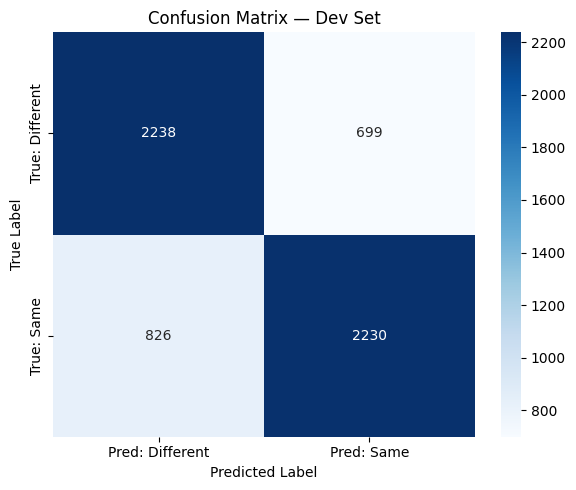

In [18]:
# --- Confusion Matrix ---
cm = confusion_matrix(dev_labels, dev_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Different', 'Pred: Same'],
            yticklabels=['True: Different', 'True: Same'], ax=ax)
ax.set_title('Confusion Matrix — Dev Set')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()


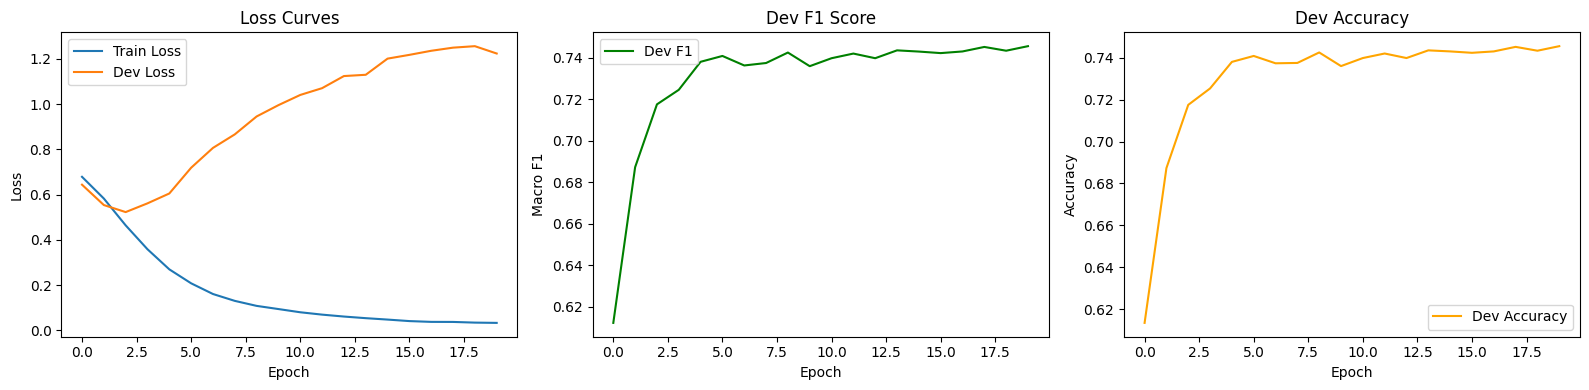

In [19]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['dev_loss'], label='Dev Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

axes[1].plot(history['dev_f1'], label='Dev F1', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Dev F1 Score')
axes[1].legend()

axes[2].plot(history['dev_acc'], label='Dev Accuracy', color='orange')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Dev Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()


## 9. Error Analysis

Understanding *where* the model fails is just as important as the overall score. This section:
1. Looks at misclassified examples to spot patterns
2. Checks if text length affects accuracy
3. Examines which stylometric features matter most

This analysis will be useful for your poster's error analysis section.


In [20]:
# --- Identify misclassified examples ---
dev_df_eval = dev_df.copy()
dev_df_eval['prediction'] = dev_preds
dev_df_eval['correct'] = (dev_df_eval['prediction'] == dev_df_eval['label']).astype(int)

errors = dev_df_eval[dev_df_eval['correct'] == 0]
print(f"Total errors: {len(errors)} / {len(dev_df_eval)} ({len(errors)/len(dev_df_eval):.2%})")
print(f"\nError breakdown:")
print(f"  False Positives (pred=1, true=0): {((dev_preds == 1) & (dev_labels == 0)).sum()}")
print(f"  False Negatives (pred=0, true=1): {((dev_preds == 0) & (dev_labels == 1)).sum()}")


Total errors: 1525 / 5993 (25.45%)

Error breakdown:
  False Positives (pred=1, true=0): 699
  False Negatives (pred=0, true=1): 826


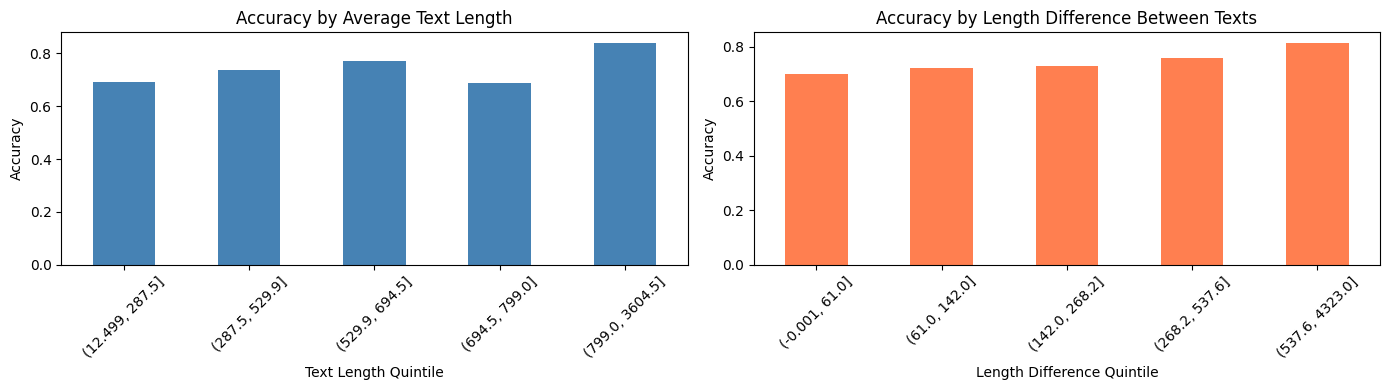

In [21]:
# --- Does text length affect accuracy? ---
dev_df_eval['avg_len'] = (dev_df_eval['len_1'] + dev_df_eval['len_2']) / 2
dev_df_eval['len_diff'] = abs(dev_df_eval['len_1'] - dev_df_eval['len_2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy by average text length
bins = pd.qcut(dev_df_eval['avg_len'], q=5)
accuracy_by_len = dev_df_eval.groupby(bins)['correct'].mean()
accuracy_by_len.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Accuracy by Average Text Length')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Text Length Quintile')
axes[0].tick_params(axis='x', rotation=45)

# Accuracy by length difference
bins2 = pd.qcut(dev_df_eval['len_diff'], q=5, duplicates='drop')
accuracy_by_diff = dev_df_eval.groupby(bins2)['correct'].mean()
accuracy_by_diff.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Accuracy by Length Difference Between Texts')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Length Difference Quintile')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [22]:
# --- Show some misclassified examples ---
print("=" * 80)
print("SAMPLE FALSE POSITIVES (predicted same author, actually different)")
print("=" * 80)
fp = errors[errors['label'] == 0].head(3)
for _, row in fp.iterrows():
    print(f"\nText 1 (first 150 chars): {row['text_1'][:150]}...")
    print(f"Text 2 (first 150 chars): {row['text_2'][:150]}...")
    print("-" * 40)

print("\n" + "=" * 80)
print("SAMPLE FALSE NEGATIVES (predicted different author, actually same)")
print("=" * 80)
fn = errors[errors['label'] == 1].head(3)
for _, row in fn.iterrows():
    print(f"\nText 1 (first 150 chars): {row['text_1'][:150]}...")
    print(f"Text 2 (first 150 chars): {row['text_2'][:150]}...")
    print("-" * 40)


SAMPLE FALSE POSITIVES (predicted same author, actually different)

Text 1 (first 150 chars): dude, which way's florida going to go? and what happened with the Cal legislature. D's get 2/3's in the senate?...
Text 2 (first 150 chars): what's up with the biz? is he an associate? ---------------------- Forwarded by Eric Bass/HOU/ECT on 08/10/2000 08:45 AM --------------------------- J...
----------------------------------------

Text 1 (first 150 chars): Paul Newman , Elizabeth Taylor , Burl Ives , Judith Anderson , Jack Carson , and Madeline Sherwood star in " Cat on a Hot Tin Roof , " a watered down ...
Text 2 (first 150 chars): Director John Milius also takes writing credit for this very colorful look at the most famous bank robber John Dillinger ( Warren Oates ) . This story...
----------------------------------------

Text 1 (first 150 chars): AAAAAAA... aaaaaaaaaa..... a-a-a-a-a...... And all together!! :) You bet I examined :) ! Was quite exciting!! :-P. And, hey Vova, don't get j

## 10. Inference / Demo Code

This section provides the demo code required for the coursework submission. Given an input CSV file with `text_1` and `text_2` columns (no labels), it loads the saved model and generates predictions.

**Important:** Make sure `best_siamese_bilstm.pt` is accessible when running this section.


In [23]:
def predict_from_file(input_path, output_path, model_path='best_siamese_bilstm.pt'):
    """
    Demo function: Load model, read test data, generate predictions.

    Args:
        input_path: Path to CSV with 'text_1' and 'text_2' columns
        output_path: Path to save predictions CSV with 'prediction' column
        model_path: Path to saved model checkpoint
    """
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=DEVICE)
    saved_vocab = checkpoint['vocab']
    saved_scaler = checkpoint['style_scaler']

    # Rebuild model
    # (In a real deployment, you'd also save/load the embedding matrix
    #  or rebuild it from the saved vocab)
    inference_model = SiameseBiLSTM(
        embedding_matrix=embedding_matrix,  # Use the same embedding matrix
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        style_feat_dim=STYLE_DIM,
        dropout=0.0  # No dropout at inference
    ).to(DEVICE)
    inference_model.load_state_dict(checkpoint['model_state_dict'])
    inference_model.eval()

    # Load test data
    test_df = pd.read_csv(input_path)
    print(f"Loaded {len(test_df)} test pairs from {input_path}")

    # Extract stylometric features
    test_style_feats, _ = compute_pair_stylometric_features(test_df)
    test_style_feats = saved_scaler.transform(test_style_feats)

    # Create dataset and loader (dummy labels)
    test_df['label'] = 0  # Placeholder
    test_dataset = AuthorshipDataset(test_df, test_style_feats, saved_vocab, MAX_LEN)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Generate predictions
    all_preds = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Predicting"):
            text1 = batch['text1'].to(DEVICE)
            text2 = batch['text2'].to(DEVICE)
            style = batch['style'].to(DEVICE)

            logits, _ = inference_model(text1, text2, style)
            preds = (torch.sigmoid(logits) >= 0.5).long()
            all_preds.extend(preds.cpu().numpy())

    # Save predictions
    pred_df = pd.DataFrame({'prediction': all_preds})
    pred_df.to_csv(output_path, index=False)
    print(f"Predictions saved to {output_path}")
    print(f"Label distribution: {pd.Series(all_preds).value_counts().to_dict()}")

    return pred_df

# --- Example usage ---
# predict_from_file('test.csv', 'Group_n_B.csv')


## 11. Save Artefacts

Save everything needed for reproducibility and the demo.


In [24]:
# Save the vocabulary and scaler separately (useful for demo code)
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

with open('style_scaler.pkl', 'wb') as f:
    pickle.dump(style_scaler, f)

print("Saved:")
print("  - best_siamese_bilstm.pt  (model checkpoint)")
print("  - vocab.pkl                (vocabulary mapping)")
print("  - style_scaler.pkl         (feature normaliser)")
print("\nThese files are needed for inference. Upload them to OneDrive")
print("if they exceed 10MB (the model likely will).")


Saved:
  - best_siamese_bilstm.pt  (model checkpoint)
  - vocab.pkl                (vocabulary mapping)
  - style_scaler.pkl         (feature normaliser)

These files are needed for inference. Upload them to OneDrive
if they exceed 10MB (the model likely will).


## Summary & Next Steps

**What we built:**
A Siamese BiLSTM with attention pooling and handcrafted stylometric features for authorship verification. This falls under **Category B** (deep learning without transformers).

**Key design choices:**
- GloVe embeddings (not transformer-based) for word representations
- Shared-weight BiLSTM encoder ensures symmetric treatment of text pairs
- Attention pooling focuses on stylistically informative parts of each text
- Stylometric features give the model explicit access to writing style signals
- Comparison via difference, product, and concatenation captures multiple aspects of similarity

**For your poster, highlight:**
- The architecture diagram (Siamese structure)
- Why stylometric features matter for authorship (vs semantic tasks)
- Dev set results table
- Error analysis findings
- Comparison with your Approach C results

**Potential improvements to try if time permits:**
- Add a character-level CNN branch alongside the word-level BiLSTM
- Experiment with different attention mechanisms (multi-head)
- Try contrastive loss as an auxiliary objective
- Tune MAX_LEN, HIDDEN_DIM, or number of LSTM layers
